In [2]:
import os
import sys
import re
import tqdm
from pathlib import Path
from dotenv import load_dotenv
import supervision as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

load_dotenv('.env')
DIR_SRC = os.getenv('DIR_SRC')
dir_s1 = Path("out") / "study2"
ls_meta = [f for f in dir_s1.iterdir() if f.suffix == '.csv' and f.name.startswith('results_')]
ls_meta

[PosixPath('out/study2/results_5.csv'),
 PosixPath('out/study2/results_3.csv'),
 PosixPath('out/study2/results_1.csv'),
 PosixPath('out/study2/results_6.csv'),
 PosixPath('out/study2/results_9.csv'),
 PosixPath('out/study2/results_0.csv'),
 PosixPath('out/study2/results_2.csv'),
 PosixPath('out/study2/results_4.csv'),
 PosixPath('out/study2/results_8.csv'),
 PosixPath('out/study2/results_7.csv')]

In [3]:
data = pd.read_csv(ls_meta[0])
for i in range(1, len(ls_meta)):
    data_tmp = pd.read_csv(ls_meta[i])
    data = pd.concat([data, data_tmp])
print(data.columns)
data.to_csv("out/backup/s2/raw.csv", index=False)
data
# study1: n (5) x split (6) x rep (20) = 600
# study2: model (5) x split (6) = 30
# total: 630

Index(['model', 'n_params', 'is_finetune', 'thread', 'iters', 'metric',
       'strategy', 'time_hptuning', 'time_inference', 'divider', 'overlap',
       'map5095', 'map50', 'precision', 'recall', 'f1', 'n_all', 'n_fn',
       'n_fp'],
      dtype='object')


,model,n_params,is_finetune,thread,iters,metric,strategy,time_hptuning,time_inference,divider,overlap,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp
0,yolo11n,2.6,2_FT,5,1,baseline,baseline,0.00,4.80,0.0,0.00,0.0001,0.0009,0.0019,0.0001,0.0002,81966,81958,4278
1,yolo11n,2.6,2_FT,5,1,count,bo_exploration,5.55,94.94,3.0,0.49,0.3686,0.6954,0.7795,0.6535,0.7110,81966,28399,15150
2,yolo11n,2.6,2_FT,5,1,count,bo_exploitation,1.19,10.55,1.0,0.28,0.0043,0.0207,0.0410,0.0066,0.0114,81966,81422,12714
3,yolo11n,2.6,2_FT,5,1,count,grid_search,8.02,129.72,4.0,0.50,0.4276,0.7283,0.8092,0.6935,0.7469,81966,25122,13399
4,yolo11n,2.6,2_FT,5,1,map,bo_exploration,10.49,44.20,2.0,0.13,0.2340,0.5249,0.6652,0.4581,0.5426,81966,44415,18900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,rtdetr-l,45.0,2_FT,7,8,baseline,baseline,0.00,7.10,0.0,0.00,0.0002,0.0011,0.0027,0.0002,0.0004,82624,82606,6722
276,rtdetr-l,45.0,2_FT,7,8,count,bo_exploration,6.06,139.50,3.0,0.47,0.3098,0.6261,0.7373,0.6107,0.6681,82624,32166,17976
277,rtdetr-l,45.0,2_FT,7,8,count,bo_exploitation,5.98,100.55,3.0,0.30,0.3062,0.6153,0.7091,0.5965,0.6479,82624,33341,20222
278,rtdetr-l,45.0,2_FT,7,8,count,grid_search,10.22,219.19,4.0,0.50,0.3507,0.6616,0.7622,0.6615,0.7083,82624,27966,17057


## Add cat column

In [4]:
data["cat"] = "X"  # default category
data.loc[data.is_finetune == "1_NOFT", "cat"] = "A_unfinetuned"
data.loc[data.is_finetune == "2_FT", "cat"] = "B_finetuned_unsupervised"
data.loc[data.metric == "map", "cat"] = "C_finetuned_supervised"

In [5]:
# calculate mean, median, std, min, max
data_sum = data.\
    query("iters <= 6").\
    groupby(['model', "cat", "strategy"]).agg(
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
    # precision
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    # recall
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
    # f1
    f1_mean=pd.NamedAgg(column='f1', aggfunc='mean'),
    f1_std=pd.NamedAgg(column='f1', aggfunc='std'),
    # time_hptuning'
    time_hptuning_mean=pd.NamedAgg(column='time_hptuning', aggfunc='mean'),
    time_hptuning_std=pd.NamedAgg(column='time_hptuning', aggfunc='std'),
    # time_inference
    time_inference_mean=pd.NamedAgg(column='time_inference', aggfunc='mean'),
    time_inference_std=pd.NamedAgg(column='time_inference', aggfunc='std'),
).reset_index()
data_sum.to_csv(Path("out") / "s2_pivot.csv", index=False)
data_sum

,model,cat,strategy,n_obs,pre_mean,pre_std,rec_mean,rec_std,f1_mean,f1_std,time_hptuning_mean,time_hptuning_std,time_inference_mean,time_inference_std
0,rtdetr-l,A_unfinetuned,baseline,60,0.001972,0.003209,0.000213,0.000445,0.000368,0.000774,0.000000,0.000000,7.418500,1.117887
1,rtdetr-l,A_unfinetuned,bo_exploitation,60,0.674765,0.107739,0.512010,0.115132,0.580688,0.113684,6.616833,2.084008,100.125500,33.099656
2,rtdetr-l,A_unfinetuned,bo_exploration,60,0.670428,0.136174,0.516023,0.136096,0.581370,0.137337,6.561833,2.215284,111.429167,42.856021
3,rtdetr-l,A_unfinetuned,grid_search,60,0.764470,0.051662,0.646532,0.037712,0.700452,0.043022,11.632667,1.144259,226.311833,12.622437
4,rtdetr-l,B_finetuned_unsupervised,baseline,60,0.003335,0.006082,0.000328,0.000600,0.000588,0.001073,0.000000,0.000000,7.641000,0.944145
5,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,60,0.699775,0.089071,0.551575,0.096926,0.615830,0.094299,7.105500,1.902723,113.574333,34.113902
6,rtdetr-l,B_finetuned_unsupervised,bo_exploration,60,0.716625,0.069244,0.574807,0.076493,0.637032,0.072639,7.299167,1.991594,135.167333,51.664821
7,rtdetr-l,B_finetuned_unsupervised,grid_search,60,0.757600,0.048853,0.640883,0.036398,0.694257,0.041001,11.790667,1.151588,228.544333,14.464847
8,rtdetr-l,C_finetuned_supervised,bo_exploitation,60,0.709558,0.087643,0.562975,0.099780,0.626423,0.094963,19.097000,8.424995,108.767833,52.910143
9,rtdetr-l,C_finetuned_supervised,bo_exploration,60,0.699093,0.118616,0.555192,0.117531,0.617540,0.118319,17.780833,8.003951,102.793833,51.849575


In [48]:
data_fig = data.melt(id_vars=["model", "cat", "strategy", "divider", "overlap"], 
                     var_name="met", value_name="score")
data_fig = data_fig.query("met in ['precision', 'recall', 'f1', 'map50', 'time_inference']")
data_fig

,model,cat,strategy,divider,overlap,met,score
16254,yolo11n,B_finetuned_unsupervised,baseline,0.0,0.00,time_inference,4.8
16255,yolo11n,B_finetuned_unsupervised,bo_exploration,3.0,0.49,time_inference,94.94
16256,yolo11n,B_finetuned_unsupervised,bo_exploitation,1.0,0.28,time_inference,10.55
16257,yolo11n,B_finetuned_unsupervised,grid_search,4.0,0.50,time_inference,129.72
16258,yolo11n,C_finetuned_supervised,bo_exploration,2.0,0.13,time_inference,44.2
...,...,...,...,...,...,...,...
32503,rtdetr-l,B_finetuned_unsupervised,baseline,0.0,0.00,f1,0.0004
32504,rtdetr-l,B_finetuned_unsupervised,bo_exploration,3.0,0.47,f1,0.6681
32505,rtdetr-l,B_finetuned_unsupervised,bo_exploitation,3.0,0.30,f1,0.6479
32506,rtdetr-l,B_finetuned_unsupervised,grid_search,4.0,0.50,f1,0.7083



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.


Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.


Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.



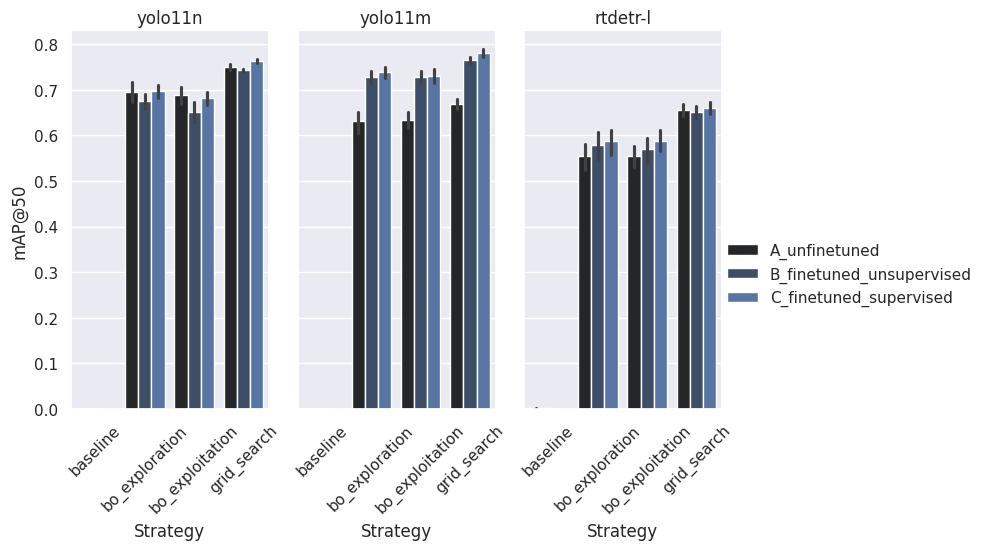

In [10]:
sns.set("notebook")
strategy_order = ["grid_search", 
                  "bo_exploration", 
                  "bo_exploitation",
                  ]
ft_order = ["1_NOFT", "2_FT"]
cat_order = [
    "A_unfinetuned",
    "B_finetuned_unsupervised",
    "C_finetuned_supervised"
]

model_order = ["yolo11n", "yolo11m", "rtdetr-l"]
g = sns.FacetGrid(
    data_fig.query("met == 'map50'"),
    col="model",
    col_order=model_order,
    margin_titles=True,
    sharey=True,
)
g.map_dataframe(sns.barplot, 
    x="strategy", 
    y="score", 
    hue="cat",
    hue_order=cat_order,
    # hue="strategy", style="strategy",
    # hue_order=strategy_order,
    # style_order=strategy_order,
    # err_style="band", errorbar=("sd", 1),
    # markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
    )
# title
# g.figure.suptitle("Model Generalization in each Data Configuration")
# g.set(
#     xscale="log",
#     xticks=[2**i for i in range(6, 11)],
#     xticklabels=[2**i for i in range(6, 11)],
#     xlabel="Number of training images (n)",)

# set x label 45 degrees
g.set_axis_labels("Strategy", "mAP@50")
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=45)
g.set_xlabels("Strategy")
g.figure.subplots_adjust(right=1.2)
g.add_legend()
g.figure.set_size_inches(10, 6)
g.savefig(Path("out") / "s2_results.png", dpi=300)

data_fig.to_csv(Path("out") / "s2_results.csv", index=False)

In [51]:
data_grid_all = data_fig.query("met in ['map50', 'time_inference']").\
                   query("strategy != 'baseline'").\
                       query("cat != 'A_unfinetuned'").\
                          query("model == 'yolo11m'")

         model                       cat        strategy  divider  overlap  \
23131  yolo11m  B_finetuned_unsupervised  bo_exploration      4.0      0.0   
21838  yolo11m  B_finetuned_unsupervised  bo_exploration      4.0      0.0   
22968  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
24159  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
21961  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
21774  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
21983  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
23840  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
21818  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
22071  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   

         met   score  
23131  map50  0.8382  
21838  map50  0.8381  
22968  map50  0.8225  
24159  map50  0.8224  
21961  map50  0.8224  
217

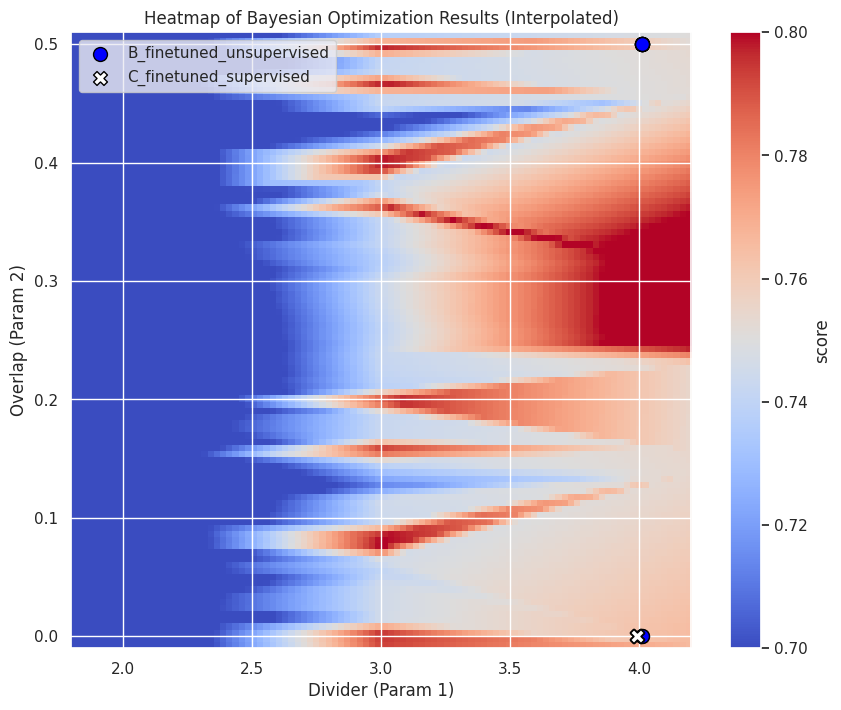

In [74]:
from scipy.interpolate import griddata

def plot_hpmap(data_grid, crange=(0.6, 0.9)):
    # Prepare data for interpolation
    x = data_grid["divider"].values
    y = data_grid["overlap"].values
    z = data_grid["score"].values
    s = data_grid["strategy"].values

    # Create a regular grid for interpolation
    grid_x, grid_y = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]

    # Interpolate the data
    grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

    # Plotting the heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(
        grid_z.T,
        # extent=(min(x), max(x), min(y), max(y)),
        extent=(1.8, 4.2, -0.01, 0.51),
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
    )
    plt.colorbar(label="score")
    # set uplimits of hue
    plt.clim(*crange)
    plt.xlabel("Divider (Param 1)")
    plt.ylabel("Overlap (Param 2)")
    plt.title("Heatmap of Bayesian Optimization Results (Interpolated)")

    df_b = data_grid[data_grid["cat"] == "B_finetuned_unsupervised"]
    df_b = df_b.sort_values(by="score", ascending=False).head(10)
    print(df_b)
    df_c = data_grid[data_grid["cat"] == "C_finetuned_supervised"]
    df_c = df_c.sort_values(by="score", ascending=False).head(10)
    print(df_c)
    plt.scatter(df_b["divider"] + .01, df_b["overlap"],
                color="blue", marker="o", label="B_finetuned_unsupervised", s=100, edgecolors='black')
    plt.scatter(df_c["divider"] - .01, df_c["overlap"],
                color="white", marker="X", label="C_finetuned_supervised", s=100, edgecolors='black')
    plt.legend()
    plt.show()

plot_hpmap(data_grid_all.query("met == 'map50'"), (0.7, 0.8))

         model                       cat        strategy  divider  overlap  \
17693  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
17715  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
17671  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
17737  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
18228  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
17117  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
18510  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
17225  yolo11m  B_finetuned_unsupervised  bo_exploration      4.0      0.5   
17506  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   
18466  yolo11m  B_finetuned_unsupervised     grid_search      4.0      0.5   

                  met   score  
17693  time_inference   169.1  
17715  time_inference  164.53  
17671  time_inference  163.99  
17737  time_i

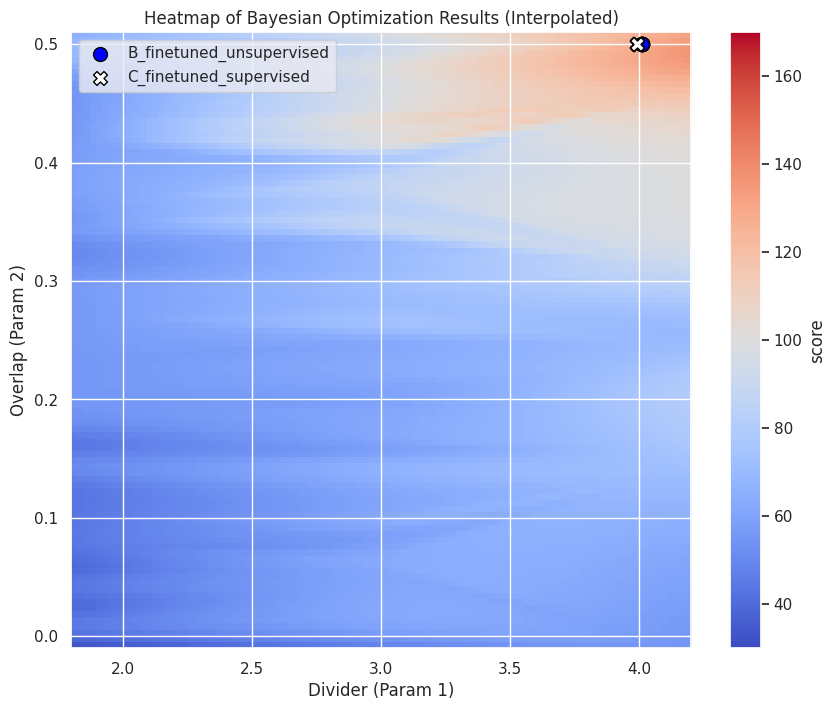

In [71]:
plot_hpmap(data_grid_all.query("met == 'time_inference'"), (30, 170))

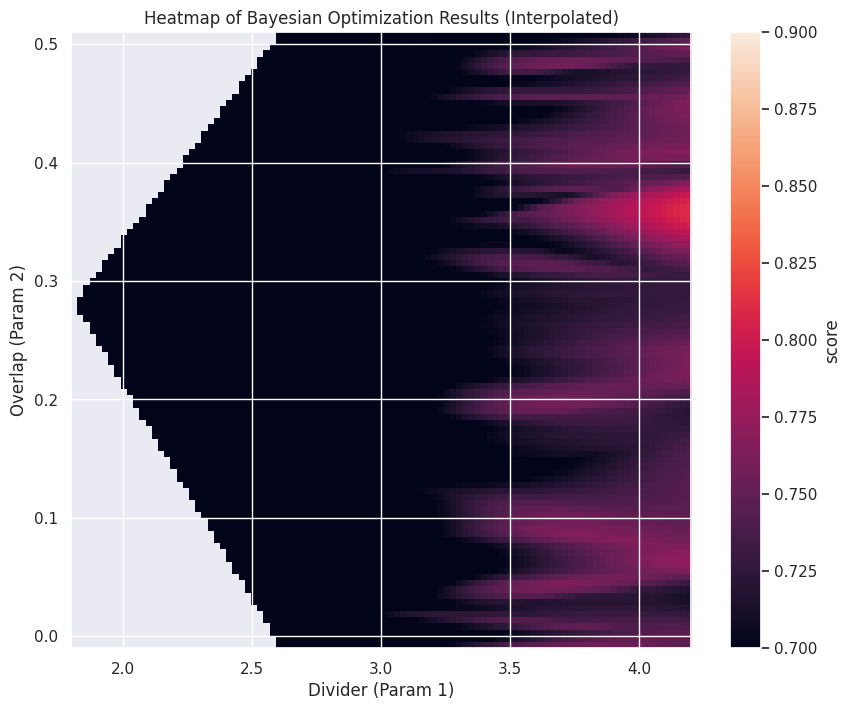

In [26]:
plot_hpmap(data_grid_all.query("model == 'yolo11n'"))